In [3]:
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv
load_dotenv()
llm=ChatOpenAI(model="gpt-5-mini")
llm

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10', 'langchain-openai': '1.3.2'}}, output_version=None, profile={'name': 'GPT-5 Mini', 'release_date': '2025-08-07', 'last_updated': '2025-08-07', 'open_weights': False, 'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': False, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x112f3c050>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x112f3cad0>, root_client=<openai.OpenAI object at 0x11240f230

In [4]:
from langchain.tools import tool

In [5]:
@tool
def tool_duck_duck_go_search(query:str) -> str:
    """use  this tool when we need to answer questions about current events
    what is happening in current time, news and event around the world """
    #tool-A
    from langchain_community.tools import DuckDuckGoSearchRun
    search=DuckDuckGoSearchRun()
    response=search.invoke(query)
    return response

In [6]:
tool_duck_duck_go_search.invoke("what is the name of Founder of Pakistan")

/var/folders/2z/pqpq9wcs0dv4jfbgkp96j3780000gn/T/ipykernel_15105/1239881137.py:6: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


'3 days ago - Muhammad Ali Jinnah (born Mahomedali Jinnahbhai; 25 December 1876 – 11 September 1948) was a barrister, statesman, and the founder of Pakistan. Jinnah served as the leader of the All-India Muslim League from 1913 until the inception of Pakistan on 14 August 1947, and then as Pakistan\'s first ... 3 hours ago - Following rigorous discussions involving Viceroy of India, Lord Mountbatten of Burma, Muhammad Ali Jinnah of the All-India Muslim League, and Jawaharlal Nehru of Congress, the formal declaration to partition British India into two independent dominions—namely Pakistan and India—was issued ... May 21, 2026 - The founders and activists of Pakistan had different occupations and came from different social strata, and many pursued more than one career simultaneously. Many founding fathers such as Muhammad Ali Jinnah, Muhammad Zafarullah Khan Liaquat ... May 22, 2026 - Muhammad Ali Jinnah (Urdu: مُحَمَّدٌ عَلَى جناح) (25 December 1876 – 11 September 1948) was a barrister,

In [7]:
@tool
def tool_wiki_pedia_search(query: str) -> str:
    #tool-B

    """use  this tool when we need to answer questions about person
    use wekipida to reply"""

    from langchain_community.tools import  WikipediaQueryRun
    from langchain_community.utilities import WikipediaAPIWrapper

    wikipedia = WikipediaQueryRun (api_wrapper=WikipediaAPIWrapper ())
    res_wiki=wikipedia.invoke(query)
    return res_wiki

In [8]:
tool_wiki_pedia_search.invoke("who is obama")

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
from langchain_core.tools import tool
import arxiv

@tool
def tool_arxiv_search(query: str, max_results: int = 3) -> list:
    #tool-C
    """
    use toll to give the top Search paper, arXiv tool give
      papers based on a query and return top results.
    """

    client = arxiv.Client()

    search = arxiv.Search(
        query=query,
        max_results=max_results,
        sort_by=arxiv.SortCriterion.SubmittedDate
    )

    results = client.results(search)

    papers = []
    for r in results:
        papers.append({
            "title": r.title,
            "published": str(r.published),
            "summary": r.summary[:300],
            "link": r.entry_id
        })

    return papers

In [9]:
tool_arxiv_search.invoke({"query": "deep learning natural language processing", "max_results": 2})

NameError: name 'tool_arxiv_search' is not defined

In [10]:
#create the tool for personal information
#tool-D
@tool
def tool_peroanl_info(query:str)->str:
    """Search personal information from database and return
    a person's name, age, and location. what is education and working domain"""

    infos=[{
        "name":"Junaid",
        "age":"20",
        "location":"Germany",
        "education":"bssc",
        "work":"IT"

    },
    {   "name":"bilal",
        "age":"22",
        "location":"Dutchland",
        "education":"bsse",
        "work":"non IT"
        }]
    
    for info in infos:
        if info["name"].lower()==query.lower():
            #return f"{info["name"]} is {info["age"]} and live in {info["location"]}"
            return f"{info['name']} is {info['age']} and lives in {info['location']}"
    return "no information"


In [11]:
tool_peroanl_info.invoke("bilal")

'bilal is 22 and lives in Dutchland'

In [12]:
#now tool is created now we will bind these tool in llm

In [13]:
llm=ChatOpenAI(model="gpt-5-mini")
llm
#llm is created

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10', 'langchain-openai': '1.3.2'}}, output_version=None, profile={'name': 'GPT-5 Mini', 'release_date': '2025-08-07', 'last_updated': '2025-08-07', 'open_weights': False, 'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': False, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x1177b2710>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x1177b2d50>, root_client=<openai.OpenAI object at 0x1177b2ad0

In [14]:
if os.path.exists("/Users/bilal/Downloads/AI/2-RAG/db"):
    print("connection is ok")
else:
    print("connection is not active")



connection is ok


In [15]:
@tool
def tool_rag(query: str)-> str:
    """use this tool when you need to answer questions based on NovaSpehere organization's documentatios"""
    from langchain_community.vectorstores import Chroma
    from langchain_openai import OpenAIEmbeddings
    embed_model=OpenAIEmbeddings(model="text-embedding-3-small")
    path_db="../2-RAG/db"
    chroma_db_connection=Chroma(persist_directory=path_db,embedding_function=embed_model)



    #1-retrive relevant documents from the vectore store
    relevent_docs=chroma_db_connection.similarity_search(query,k=2)
    relevent_docs_content= "\n".join([doc.page_content for doc in relevent_docs])
    return relevent_docs_content


In [16]:
tool_rag.invoke("what is novs")

/var/folders/2z/pqpq9wcs0dv4jfbgkp96j3780000gn/T/ipykernel_15105/3663827809.py:8: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  chroma_db_connection=Chroma(persist_directory=path_db,embedding_function=embed_model)


'NovaSphere Technologies is a fictional organization created to represent a modern data\nNovaSphere Technologies is a fictional organization created to represent a modern data'

In [17]:
@tool
def tool_rag_semantic(query: str)-> str:
    """use this tool when you need to answer questions based on NovaSpehere organization's documentatios"""
    from langchain_community.vectorstores import Chroma
    from langchain_openai import OpenAIEmbeddings
    embed_model=OpenAIEmbeddings(model="text-embedding-3-small")
    path_db2="./chroma_db_semantic"
    chroma_db_connection=Chroma(persist_directory=path_db2,embedding_function=embed_model)



    #1-retrive relevant documents from the vectore store
    relevent_docs=chroma_db_connection.similarity_search(query,k=2)
    relevent_docs_content= "\n".join([doc.page_content for doc in relevent_docs])
    return relevent_docs_content


In [18]:
tool_rag_semantic.invoke("When was NovaSphere Organization founded?")

'NovaSphere Technologies is a fictional organization created to represent a modern data \nand technology company that has grown gradually over the years. The organization was \nfounded in 2016 by a small group of software engineers who strongly believed that data \nwould become one of the most valuable assets for every business in the future.\nThe founders also started planning \nthe next stage of growth, which included expanding into new regions and working with \ninternational clients. Today, NovaSphere Technologies is considered a reliable organization that provides data \nengineering and analytics services to companies from different industries such as finance, \nhealthcare, retail, and e-commerce. Even though the company has grown significantly \nsince 2016, the original vision has not changed. The focus is still on learning continuously, \nimproving the quality of work, and helping organizations make better decisions using data. The company believes that the future of business wi

In [19]:
# to bind , we need bind tool kit

In [21]:
tool_kit=[

    tool_duck_duck_go_search,
    tool_wiki_pedia_search,
    #tool_arxiv_search,
    tool_peroanl_info,
    tool_rag, 
    tool_rag_semantic

]

In [22]:
tool_kit

[StructuredTool(name='tool_duck_duck_go_search', description='use  this tool when we need to answer questions about current events\nwhat is happening in current time, news and event around the world', args_schema=<class 'langchain_core.utils.pydantic.tool_duck_duck_go_search'>, func=<function tool_duck_duck_go_search at 0x112f27600>),
 StructuredTool(name='tool_wiki_pedia_search', description='use  this tool when we need to answer questions about person\nuse wekipida to reply', args_schema=<class 'langchain_core.utils.pydantic.tool_wiki_pedia_search'>, func=<function tool_wiki_pedia_search at 0x11379d800>),
 StructuredTool(name='tool_peroanl_info', description="Search personal information from database and return\na person's name, age, and location. what is education and working domain", args_schema=<class 'langchain_core.utils.pydantic.tool_peroanl_info'>, func=<function tool_peroanl_info at 0x1177e2340>),
 StructuredTool(name='tool_rag', description="use this tool when you need to an

In [23]:
llm_bind=llm.bind_tools(tool_kit)
llm_bind
#. bind tool that allow to bind the tool with llm

_ChatModelBinding(bound=ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10', 'langchain-openai': '1.3.2'}}, output_version=None, profile={'name': 'GPT-5 Mini', 'release_date': '2025-08-07', 'last_updated': '2025-08-07', 'open_weights': False, 'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': False, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x1177b2710>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x1177b2d50>, root_client=<openai.Open

In [24]:
#now i will call the llm and ask the age of bilal, it will pick the information but not final and give suggestion
#to solve this we need agent , it will works as loop and fectch the exact information
#this is reason and act, we use react agent class in llm

In [25]:
llm_bind.invoke("what the current location of bilal in database")

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 91, 'prompt_tokens': 312, 'total_tokens': 403, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DuBNgrpKHyasXAHdhqfvNY9ERSc2U', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ef850-86fa-7531-8185-394db7ec98d7-0', tool_calls=[{'name': 'tool_peroanl_info', 'args': {'query': 'bilal'}, 'id': 'call_xI86b13yQUOgEGdS001qlFHk', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 312, 'output_tokens': 91, 'total_tokens': 403, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 64}})

In [26]:
llm_bind = llm.bind_tools(tool_kit)

response = llm_bind.invoke("what is the professioanl of person name is bilal? His location is Dutchland")
print(response)

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 157, 'prompt_tokens': 322, 'total_tokens': 479, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DuBNiNDq9AV71IqoNnMmMD1UYpyX1', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019ef850-91ba-7c23-bdbe-5a892d6ce641-0' tool_calls=[{'name': 'tool_peroanl_info', 'args': {'query': 'Bilal Dutchland'}, 'id': 'call_6l9l7gH4sdIgNoPgfKSF7tYP', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 322, 'output_tokens': 157, 'total_tokens': 479, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 128}}


In [27]:
#reAct Agent

In [28]:
from langchain.agents import create_agent

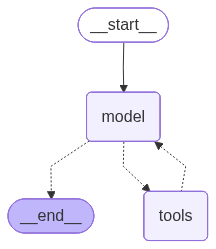

In [29]:
my_agent=create_agent(llm_bind, tools=tool_kit)
my_agent

In [30]:
my_agent.invoke(
{"messages":[{"role": "user", "content":"what is the education of person name is junaid whose location is Germany and bilal is public figure and work as IT}"
}]})

{'messages': [HumanMessage(content='what is the education of person name is junaid whose location is Germany and bilal is public figure and work as IT}', additional_kwargs={}, response_metadata={}, id='f97528fa-89a7-48c0-ba93-74f06efc4140'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 261, 'prompt_tokens': 329, 'total_tokens': 590, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DuBNo4J8dMJyA5eTXucmxSUy3RaVn', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ef850-a262-7c12-8099-a73fa661eaa5-0', tool_calls=[{'name': 'tool_peroanl_info', 'args': {'query': 'Junaid location Germany education'}, 'id': 'call_gw

In [31]:
from langchain_core.messages import HumanMessage

my_agent.invoke({
    "messages": [HumanMessage(content="WHAT IS THE EDUCATION OF BILAL")]
})

{'messages': [HumanMessage(content='WHAT IS THE EDUCATION OF BILAL', additional_kwargs={}, response_metadata={}, id='e9ebf90a-ace6-4148-a956-b0602c44adf5'),
  AIMessage(content="Which Bilal do you mean? Provide a full name or some context (e.g., Bilal the singer, Bilal ibn Rabah, Bilal Powell, Bilal Ahmed, a friend/colleague, etc.). If you want me to look up a public figure, I can search and summarize their education; if it's a private person, I may not have access to their details.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 280, 'prompt_tokens': 312, 'total_tokens': 592, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DuBO0lnqWrdEYh94k1p2SEdvmWMYe', 'service_tier': 'd

In [32]:

my_agent.invoke(
    {"messages": [{"role": "user", "content": "What's the age of Junaid?. Make tool calls if necessary."}]}
)

{'messages': [HumanMessage(content="What's the age of Junaid?. Make tool calls if necessary.", additional_kwargs={}, response_metadata={}, id='3cad6f87-a834-40b5-bdda-81ed6e1da598'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 92, 'prompt_tokens': 317, 'total_tokens': 409, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DuBO4ikfdHr5JxudAU0lKRyOc1Ymy', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ef850-e8e5-7342-93bf-70351ace742b-0', tool_calls=[{'name': 'tool_peroanl_info', 'args': {'query': 'Junaid'}, 'id': 'call_zm7YSpHMxkrEjfQBqMYLkpJ4', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'

In [33]:

a=my_agent.invoke(
    {"messages": [{"role": "user", "content": "when was NovaSphere organization founded?"}]}
)
a

{'messages': [HumanMessage(content='when was NovaSphere organization founded?', additional_kwargs={}, response_metadata={}, id='f10a29e8-ccb4-4d26-a884-46d561a542f8'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 159, 'prompt_tokens': 310, 'total_tokens': 469, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DuBO94w849Zmt5fhwB826d2gO0pWC', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ef850-fbae-7b21-80b2-6839a77b8192-0', tool_calls=[{'name': 'tool_rag_semantic', 'args': {'query': 'When was NovaSphere founded?'}, 'id': 'call_6zDFTtuznlQxKJ6j7dXfphrm', 'type': 'tool_call'}], invalid_tool_calls=[], usage_me

In [34]:

my_agent.invoke(
    {"messages": [{"role": "user", "content": "when was NovaSphere organization founded?"}]}
)

{'messages': [HumanMessage(content='when was NovaSphere organization founded?', additional_kwargs={}, response_metadata={}, id='9d387167-c5bb-4e14-85d2-a387f623b96d'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 310, 'total_tokens': 342, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DuBOG8gxXiM9GPvseVdrkzJkUtg5v', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ef851-1772-71e2-9e63-d27fb47bba02-0', tool_calls=[{'name': 'tool_rag_semantic', 'args': {'query': 'When was NovaSphere organization founded?'}, 'id': 'call_B0cIaSYpmCcwU77gerO0KCnk', 'type': 'tool_call'}], invalid_tool_calls=[]

In [35]:

my_agent.invoke(
    {"messages": [{"role": "user", "content": "please summerize it fot me"}]}
)

{'messages': [HumanMessage(content='please summerize it fot me', additional_kwargs={}, response_metadata={}, id='c62d3260-f9ba-4172-b66b-5e6734c23c6d'),
  AIMessage(content='I’m missing the text or link you want summarized. Could you paste the content here or upload/link the file? \n\nAlso tell me:\n- Desired length/style (one-sentence TL;DR, 3–5 bullet points, 150–300 word summary, or detailed section-by-section summary).\n- Any focus (main ideas, action items, pros/cons, important quotes, technical details).\n- If there’s a word limit or audience (e.g., for executives, classmates, or publication).\n\nExamples you can request:\n- “Give me a one-sentence TL;DR.”\n- “Summarize in 5 bullets with key takeaways.”\n- “Write a 200-word summary for a non-technical audience.”\n\nShare the content and your preferences and I’ll summarize it.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 361, 'prompt_tokens': 309, 'total_tokens': 670, 'completion_t

In [36]:
#Memory, it will save the information in folder, db and data lake or memory

In [37]:

founded_date=my_agent.invoke(
    {"messages": [{"role": "user", "content": "when was NovaSphere organization founded?"}]}
) 
founded_date['messages']

[HumanMessage(content='when was NovaSphere organization founded?', additional_kwargs={}, response_metadata={}, id='e3caf25a-2576-4e58-b093-7c87836768c6'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 96, 'prompt_tokens': 310, 'total_tokens': 406, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DuBOYKUVaoXnnBUdkIobB2WIEhetf', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ef851-5c6c-7081-9794-148eb655a880-0', tool_calls=[{'name': 'tool_rag_semantic', 'args': {'query': 'When was NovaSphere organization founded?'}, 'id': 'call_9oAH3LtoLD3OxsdBAkjSMoAp', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metad

In [38]:
#create the memory list

In [39]:
agent_memory = []

def invoke_agent_with_memory(query: str):

    response_memory = my_agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": f"Answer this: {query}. You can use previous memory interactions: {agent_memory}"
                }
            ]
        }
    )

    agent_memory.append({
        "query": query,
        "response": response_memory
    })

    #if you want to save tokens then use below 

    agent_memory.append(response_memory['messages'])
    #agent_memory.extend(response_memory['messages'])





    return response_memory

In [59]:
invoke_agent_with_memory("when NovaSphere organization was founded?")

{'messages': [HumanMessage(content='Answer this: when NovaSphere organization was founded?. You can use previous memory interactions: []', additional_kwargs={}, response_metadata={}, id='ccdf973c-8a43-42cd-a3b5-268fa1c4db23'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 375, 'total_tokens': 407, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-Du470P1kQDMf794HalTrbLLWIhaXN', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ef6a6-29e9-78e0-9738-77870aaede58-0', tool_calls=[{'name': 'tool_rag_semantic', 'args': {'query': 'When was NovaSphere organization founded?'}, 'id': 'call_r7iDrfTo7hlU

In [60]:
invoke_agent_with_memory("create the two lines summary of previous interation")

{'messages': [HumanMessage(content="Answer this: create the two lines summary of previous interation. You can use previous memory interactions: [HumanMessage(content='Answer this: when NovaSphere organization was founded?. You can use previous memory interactions: []', additional_kwargs={}, response_metadata={}, id='ccdf973c-8a43-42cd-a3b5-268fa1c4db23'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 375, 'total_tokens': 407, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-Du470P1kQDMf794HalTrbLLWIhaXN', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ef6a6-29e9-78e0-9738-77870aaede58-0', t

In [40]:
agent_memory

[]

In [62]:
#chat boot 

In [43]:
while True:
    query=input("Ask any Qusestion")
    reply=invoke_agent_with_memory(query=query)
    print(reply)
    flag=input("Anything else")
    if flag.lower()=="no":
        print("SEE YOU AGAIN")
        break

{'messages': [HumanMessage(content='Answer this: what was my name ?. You can use previous memory interactions: [{\'query\': \'hi my name is bilal\', \'response\': {\'messages\': [HumanMessage(content=\'Answer this: hi my name is bilal. You can use previous memory interactions: []\', additional_kwargs={}, response_metadata={}, id=\'c27d1652-edcb-4a3f-b127-1d4984fb128a\'), AIMessage(content="Hi Bilal — nice to meet you! I don\'t have any previous memories for you (you indicated []). I can remember your name for the rest of this chat, and if you\'d like, I can keep it for future conversations — want me to do that? How can I help you today?", additional_kwargs={\'refusal\': None}, response_metadata={\'token_usage\': {\'completion_tokens\': 260, \'prompt_tokens\': 321, \'total_tokens\': 581, \'completion_tokens_details\': {\'accepted_prediction_tokens\': 0, \'audio_tokens\': 0, \'reasoning_tokens\': 192, \'rejected_prediction_tokens\': 0}, \'prompt_tokens_details\': {\'audio_tokens\': 0, \'

In [44]:
agent_memory

[{'query': 'hi my name is bilal',
  'response': {'messages': [HumanMessage(content='Answer this: hi my name is bilal. You can use previous memory interactions: []', additional_kwargs={}, response_metadata={}, id='c27d1652-edcb-4a3f-b127-1d4984fb128a'),
    AIMessage(content="Hi Bilal — nice to meet you! I don't have any previous memories for you (you indicated []). I can remember your name for the rest of this chat, and if you'd like, I can keep it for future conversations — want me to do that? How can I help you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 260, 'prompt_tokens': 321, 'total_tokens': 581, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DuBP6z0ejNqB